# Toy model results
This jupyter notebook generates the RSM variability results on the toy model. It generates the corresponding figures in the paper *Data symmetries can confound representational similarity analyses*.


# Setup and Functions

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib as mpl
import os
fig_folder = 'output'
save_figures = True
if save_figures and not os.path.exists(fig_folder):
    os.makedirs(fig_folder)
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['font.size'] = 14
mpl.rcParams['image.cmap'] = 'magma'
# write a function that takes the parameters as input, returns weights, stimuli, responses, RSM
def relu(x):
    return np.maximum(0, x)
def neuron_response(stimuli, weights, bias):
    return relu(weights.T @ stimuli - np.reshape(bias, (-1, 1)))


def RF_responses(stimuli, RF_angles, RF_amps, tuning_width):
    weight_mags = np.divide(RF_amps, 1 - np.cos(tuning_width/2))
    biases = np.multiply(weight_mags, np.cos(tuning_width/2))
    weights = np.array([weight_mags[i]*np.array([np.cos(a), np.sin(a)]) for i,a in enumerate(RF_angles)]).T
    H = neuron_response(stimuli, weights, biases)
    RSM = H.T @ H
    RSM_normalized = np.zeros_like(RSM)
    for i in range(RSM.shape[0]):
        for j in range(RSM.shape[1]):
            RSM_normalized[i, j] = RSM[i, j] / np.sqrt(RSM[i, i] * RSM[j, j])
    return H, RSM, RSM_normalized


def plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM, tag='', savefigfile = None, figsize=(12,4), only_RF=False):
    # Plot RFs as a function of angle and RSM and RSM_normalized
    plt.figure(figsize=figsize)
    if not only_RF:
        plt.subplot(1, 3, 1)
    angles = np.linspace(0, 2 * np.pi, 100, endpoint=False)
    num_neurons = len(RF_angles)
    for i in range(num_neurons):
        RF_angle = RF_angles[i]
        RF_amp = RF_amps[i]
        tuning_curve = RF_amp * relu(np.cos(angles - RF_angle) - np.cos(tuning_width[i]/2))
        #plt.polar(angles, tuning_curve, label=f'Neuron {i+1}')
        plt.plot(angles, tuning_curve, label=f'Neuron {i+1}')
    plt.title(tag)
    plt.xlabel('Angle')
    plt.ylabel('Response')
    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
    plt.xticks(ticks, tick_labels)
    plt.grid(True)
    
    # Prepare angle tick positions and labels for imshow plots
    if not only_RF:
        num_stimuli = RSM.shape[0]
        angle_ticks_positions = [0, num_stimuli/4, num_stimuli/2, 3*num_stimuli/4, num_stimuli-1]
        angle_tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
        
        plt.subplot(1, 3, 2)
        plt.imshow(RSM, aspect='auto', interpolation='none', 
                extent=[0, 2*np.pi, 2*np.pi, 0])  # Map indices to angles
        plt.colorbar(label='RSM Value', shrink=0.75)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlabel('Stimulus Angle')
        plt.ylabel('Stimulus Angle')
        plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], angle_tick_labels)
        plt.yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], angle_tick_labels)
        plt.title('RSM')

        plt.subplot(1, 3, 3)
        plt.imshow(RSM_normalized, aspect='auto', interpolation='none',
                extent=[0, 2*np.pi, 2*np.pi, 0])  # Map indices to angles
        plt.colorbar(label='Normalized RSM Value', shrink=0.75)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlabel('Stimulus Angle')
        plt.ylabel('Stimulus Angle')
        plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], angle_tick_labels)
        plt.yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], angle_tick_labels)
        plt.title('Normalized RSM')
        plt.tight_layout()
    if savefigfile is not None:
        plt.savefig(savefigfile)




# Plot RFs and RSMs for two different $\varphi$'s $(n=4)$

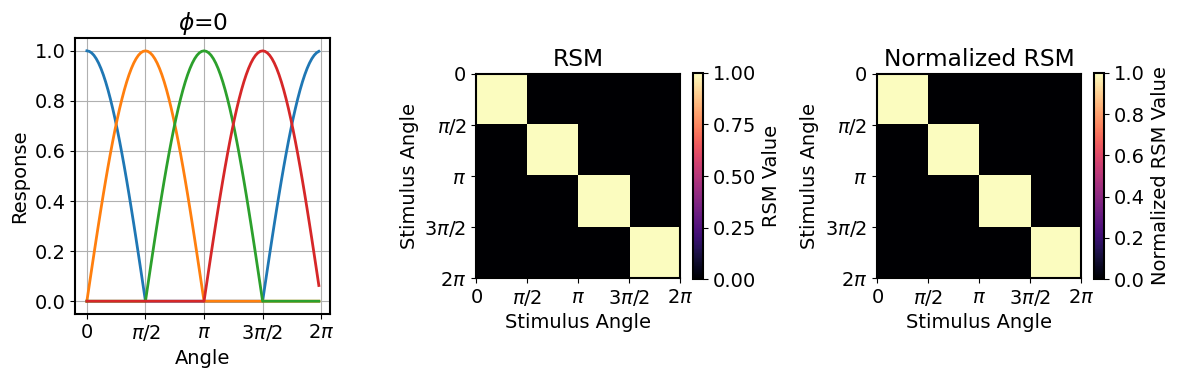

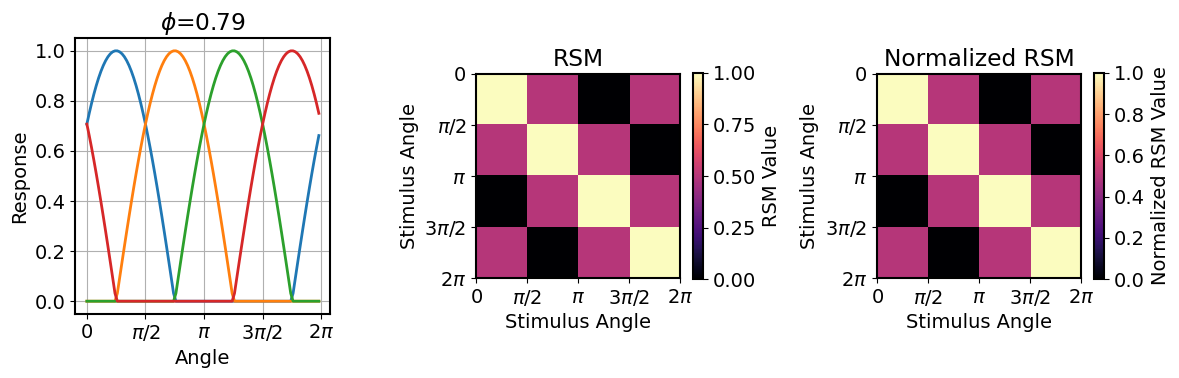

In [3]:
num_neurons = 4
num_stims = 4
phi = 0*np.pi/4
tuning_width_base = (np.pi)
amp_change_sigma = 0.0

tuning_width = tuning_width_base * np.ones(num_neurons)
RF_amps = 1* np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T
stimuli_angles = np.linspace(0, 2 * np.pi, num_stims, endpoint=False)

H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM, '$\phi$=0')
# save as svg
if save_figures:
    plt.savefig(fig_folder + '/n=4_RF_tuning_curve_and_RSM_phi0.svg')


num_neurons = 4
num_stims = 4
phi = 1*np.pi/4
amp_change_sigma = 0.0

tuning_width = tuning_width_base * np.ones(num_neurons)
RF_amps = 1* np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T

H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM, '$\phi$='+str(round(phi,2)))
# save as svg
if save_figures:
    plt.savefig(fig_folder + '/n=4_RF_tuning_curve_and_RSM_phi_pi4.svg')


# Plot RSM entries vs. $\varphi$

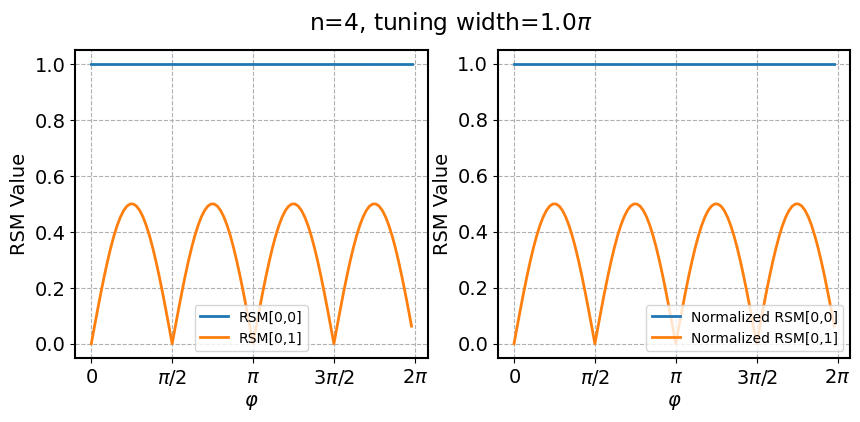

In [4]:
num_neurons = 4
num_stims = 4
tuning_width_base = (np.pi)
amp_change_sigma = 0.0

Hs =[]; RSMs = []; RSMs_normalized = []
phis = np.linspace(0, 2*np.pi, 100, endpoint=False)
RF_amps = 1*np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T



for phi in phis:
    tuning_width = tuning_width_base * np.ones(num_neurons)
    RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
    H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
    Hs.append(H)
    RSMs.append(RSM)
    RSMs_normalized.append(RSM_normalized)
    # if phi == phis[0]:
    #     plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM)
Hs = np.array(Hs)
RSMs = np.array(RSMs)
RSMs_normalized = np.array(RSMs_normalized)

# Do a 1 x 2 subplot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(phis, RSMs[:,0,0], label='RSM[0,0]', color = 'tab:blue')
#plt.plot(phis, RSMs[:,1,1], label='RSM[1,1]', color = 'tab:green')
plt.plot(phis, RSMs[:,0,1], label='RSM[0,1]', color = 'tab:orange')
plt.xlabel(r'$\varphi$')
plt.ylabel('RSM Value')
# Set tick positions in radians
ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
# Set tick labels as LaTeX
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]

plt.xticks(ticks, tick_labels)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--")
# second 
plt.subplot(1, 2, 2)
plt.plot(phis, RSMs_normalized[:,0,0], label='Normalized RSM[0,0]', color = 'tab:blue')
plt.plot(phis, RSMs_normalized[:,0,1], label='Normalized RSM[0,1]', color = 'tab:orange')
plt.xlabel(r'$\varphi$')
plt.ylabel('RSM Value')
plt.xticks(ticks, tick_labels)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--")
plt.suptitle('n=' + str(num_neurons) +', tuning width='+ str(round(tuning_width[0]/np.pi,3)) + r'$\pi$')
if save_figures:
    plt.savefig(fig_folder + '/n=4_RF_RSM_entries_vs_phi.svg')

# Similarity Matching Loss vs. $\varphi$

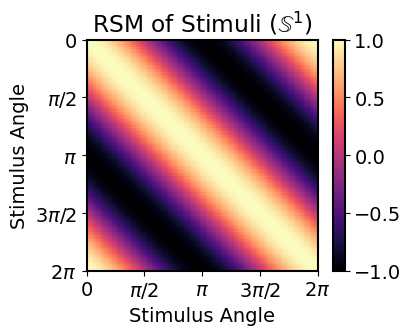

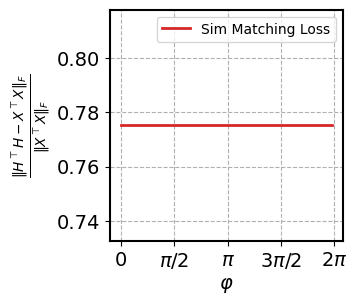

In [5]:
num_neurons = 4
num_stims = 100
tuning_width_base = (np.pi)
amp_change_sigma = 0.0

Hs =[]; RSMs = []; RSMs_normalized = []
phis = np.linspace(0, 2*np.pi, 100, endpoint=False)
RF_amps = 1*np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T


for phi in phis:
    tuning_width = tuning_width_base * np.ones(num_neurons)
    RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
    H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
    Hs.append(H)
    RSMs.append(RSM)
    RSMs_normalized.append(RSM_normalized)
Hs = np.array(Hs)
RSMs = np.array(RSMs)
RSMs_normalized = np.array(RSMs_normalized)

from sklearn.metrics.pairwise import cosine_similarity
RSM_stimuli_normalized = cosine_similarity(stimuli.T)
#sim_matching_loss_per_phis = [np.linalg.norm(RSMs_normalized[i] - RSM_stimuli_normalized, 'fro')/np.linalg.norm(RSM_stimuli_normalized, 'fro') for i in range(len(phis))]
num_stims = stimuli.shape[1]
sim_matching_loss_per_phis = [(np.linalg.norm(RSMs[i] - RSM_stimuli_normalized, 'fro'))/np.linalg.norm(RSM_stimuli_normalized, 'fro') for i in range(len(phis))]


# Plot RSM of stimuli
plt.figure(figsize=(4, 3))
plt.imshow(RSM_stimuli_normalized, aspect='equal', interpolation='none', extent=[0, 2*np.pi, 2*np.pi, 0])
plt.colorbar()
plt.title('RSM of Stimuli ($\mathbb{S}^1$)')
ax = plt.gca()
ax.set_xlabel('Stimulus Angle')
ax.set_ylabel('Stimulus Angle')
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
if save_figures:
    plt.savefig(fig_folder + '/n=4_stimuli_RSM.svg')



plt.figure(figsize=(3, 3))
plt.plot(phis, sim_matching_loss_per_phis, label='Sim Matching Loss', color = 'tab:red')
plt.xlabel(r'$\varphi$')
#plt.ylabel(r'$\|Y^{\top}Y - X^{\top}X\|_F/\|X^{\top}X\|_F$')
plt.ylabel(r'$\frac{\|H^{\top}H - X^{\top}X\|_F}{\|X^{\top}X\|_F}$')
plt.xticks(ticks, tick_labels)
plt.gca().set_aspect('auto')
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--")
if save_figures:
    plt.savefig(fig_folder + '/n=4_similarity_matching_loss_vs_phi.svg')


# Plot CKA matrices

0.8164965809277261
0.8164965809277259


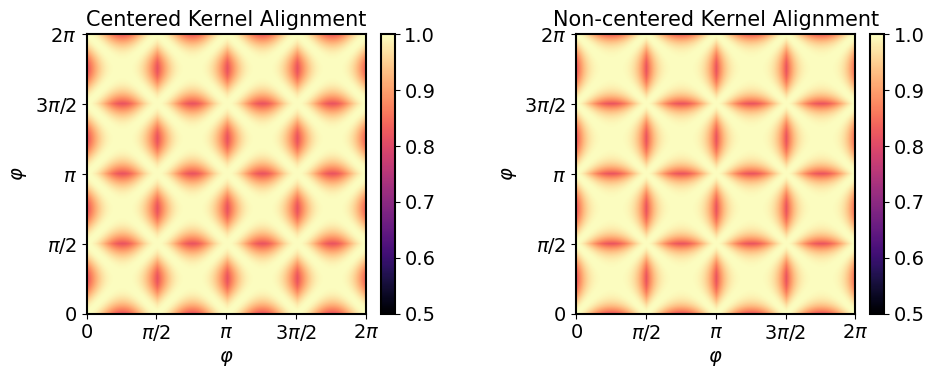

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ---- your CKA code from earlier ----
def _center_gram(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def kernel_cka(K, L, centered=True):
    if centered:
        K = _center_gram(K)
        L = _center_gram(L)
    num = np.sum(K * L)
    denom = np.sqrt(np.sum(K * K) * np.sum(L * L))
    return num / denom

def cka(K, L, centered=True):
    # Here we assume K,L are already Gram/RSM matrices
    return kernel_cka(K, L, centered=centered)


# -------- parameters --------
num_neurons = 4
num_stims = 4
tuning_width_base = np.pi
amp_change_sigma = 0.0

num_phis = 360  # e.g., 36 orientations from 0 to 2π
phis = np.linspace(0, 2 * np.pi, num_phis, endpoint=False)

# Precompute stimuli (same for all phi)
stimuli_angles = np.linspace(0, 2 * np.pi, num_stims, endpoint=False)
stimuli = np.array([
    [np.cos(a), np.sin(a)] for a in stimuli_angles
]).T   # shape: (2, num_stims)

# Containers for RSMs (use normalized version; change if you want plain RSM)
RSMs = []

for phi in phis:
    tuning_width = tuning_width_base * np.ones(num_neurons)
    RF_amps = 1 * np.ones(num_neurons) + amp_change_sigma * np.random.randn(num_neurons)
    RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)

    H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
    RSMs.append(RSM_normalized)

RSMs = np.array(RSMs)  # shape: (num_phis, num_stims, num_stims)

# -------- pairwise CKA across phis --------
cka_centered = np.zeros((num_phis, num_phis))
cka_noncentered = np.zeros((num_phis, num_phis))

for i in range(num_phis):
    for j in range(num_phis):
        K = RSMs[i]
        L = RSMs[j]
        cka_centered[i, j] = cka(K, L, centered=True)
        cka_noncentered[i, j] = cka(K, L, centered=False)

import numpy as np
import matplotlib.pyplot as plt

# -------- plotting --------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Use extent so axes are in units of phi (radians)
extent = [0, 2 * np.pi, 0, 2 * np.pi]

im0 = axes[0].imshow(
    cka_centered,
    origin='lower',
    vmin=0.5, vmax=1,
    extent=extent,
    aspect='equal'
)
axes[0].set_title('Centered Kernel Alignment', fontsize=15)
axes[0].set_xlabel(r'$\varphi$')
axes[0].set_ylabel(r'$\varphi$')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(
    cka_noncentered,
    origin='lower',
    vmin=0.5, vmax=1,
    extent=extent,
    aspect='equal'
)
axes[1].set_title('Non-centered Kernel Alignment', fontsize=15)
axes[1].set_xlabel(r'$\varphi$')
axes[1].set_ylabel(r'$\varphi$')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Tick positions and LaTeX labels
tick_positions = [0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2 * np.pi]
tick_labels = [r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']

for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_yticklabels(tick_labels)

plt.tight_layout()
#plt.show()
if save_figures:
    plt.savefig(fig_folder + '/n=4_CKA_centered_vs_noncentered.svg')
print(np.min(cka_noncentered.flatten()))
print(np.min(cka_centered.flatten()))

# Plot RSM entries vs. $\varphi$ for different $n$ and tuning width

Text(0.5, 0.98, 'n=12, tuning width=0.333$\\pi$')

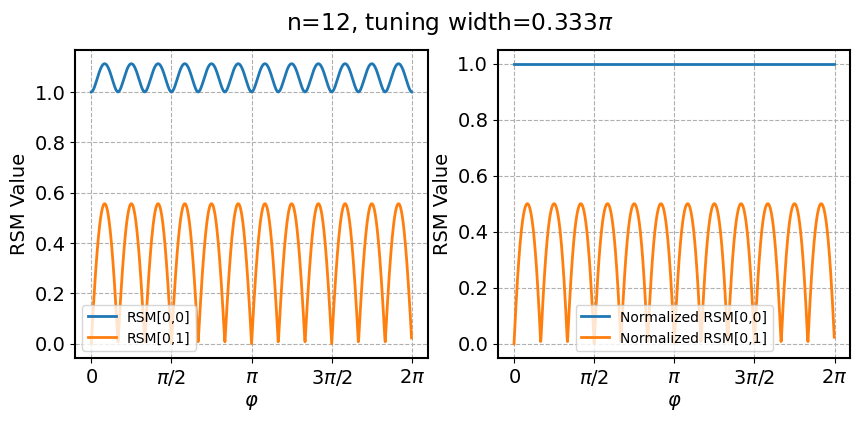

In [16]:
num_neurons = 12
tuning_width_base = (np.pi)/3
num_stims = int(4*np.pi/tuning_width_base) # This ensures alpha=tuning_width_base/2 (corresponding to RSM[:,1])
amp_change_sigma = 0.0

Hs =[]; RSMs = []; RSMs_normalized = []
phis = np.linspace(0, 2*np.pi, 1000, endpoint=False)
RF_amps = 1*np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T

for phi in phis:
    tuning_width = tuning_width_base * np.ones(num_neurons)
    RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
    H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
    Hs.append(H)
    RSMs.append(RSM)
    RSMs_normalized.append(RSM_normalized)
    # if phi == phis[0]:
    #     plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM, '$\phi$='+str(round(phi,2)))
Hs = np.array(Hs)
RSMs = np.array(RSMs)
RSMs_normalized = np.array(RSMs_normalized)
RSM_var = np.max(RSMs_normalized, axis=0) - np.min(RSMs_normalized, axis=0)


# Do a 1 x 2 subplot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(phis, RSMs[:,0,0], label='RSM[0,0]', color = 'tab:blue')
#plt.plot(phis, RSMs[:,1,1], label='RSM[1,1]', color = 'tab:green')
plt.plot(phis, RSMs[:,0,1], label='RSM[0,1]', color = 'tab:orange')
plt.xlabel(r'$\varphi$')
plt.ylabel('RSM Value')
# Set tick positions in radians
ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
# Set tick labels as LaTeX
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]

plt.xticks(ticks, tick_labels)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--")
# second 
plt.subplot(1, 2, 2)
plt.plot(phis, RSMs_normalized[:,0,0], label='Normalized RSM[0,0]', color = 'tab:blue')
#plt.plot(phis, RSMs_normalized[:,1,1], label='Normalized RSM[1,1]', color = 'tab:green')
plt.plot(phis, RSMs_normalized[:,0,1], label='Normalized RSM[0,1]', color = 'tab:orange')
plt.xlabel(r'$\varphi$')
plt.ylabel('RSM Value')
plt.xticks(ticks, tick_labels)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--")
plt.suptitle('n=' + str(num_neurons) +', tuning width='+ str(round(tuning_width[0]/np.pi,3)) + r'$\pi$')

# Plot RSM variability ($\Delta$) as a function of stimuli angle difference ($\alpha$)

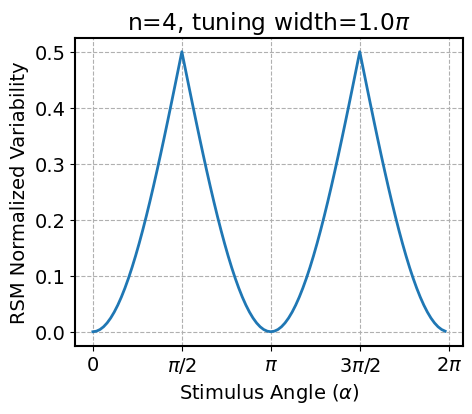

In [17]:
num_neurons = 4
num_stims = 100
tuning_width_base = 1.0*(np.pi)
amp_change_sigma = 0.0

Hs =[]; RSMs = []; RSMs_normalized = []
phis = np.linspace(0, 2*np.pi, 1000, endpoint=False)
RF_amps = 1*np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T
stimuli_angles = [a/np.pi for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]


for phi in phis:
    tuning_width = tuning_width_base * np.ones(num_neurons)
    RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
    H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
    Hs.append(H)
    RSMs.append(RSM)
    RSMs_normalized.append(RSM_normalized)
    # if phi == np.pi/4:
    #     savefigfile = fig_folder + '/n=4_RF_tuning_curve_and_RSM_phi' + str(round(phi,2)) + '.svg'
    #     plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM, '$\phi$='+str(round(phi,2)), savefigfile=savefigfile)
Hs = np.array(Hs)
RSMs = np.array(RSMs)
RSMs_normalized = np.array(RSMs_normalized)
RSM_var = np.max(RSMs_normalized, axis=0) - np.min(RSMs_normalized, axis=0)


delta = np.max(RSMs_normalized[:,0,:], axis=0) - np.min(RSMs_normalized[:,0,:], axis=0)
plt.figure(figsize=(5,4))
plt.plot(stimuli_angles, delta, '-')
# change x labels to 2pi
plt.xticks([0, 0.5, 1, 1.5, 2], [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
plt.xlabel(r'Stimulus Angle ($\alpha$)')
plt.ylabel('RSM Normalized Variability')
plt.title('n='+str(num_neurons) + ', tuning width='+ str(round(tuning_width[0]/np.pi,3)) + r'$\pi$')
plt.grid(True, which="both", ls="--")
if save_figures:
    plt.savefig(fig_folder + '/n=' + str(num_neurons) + 'TW' + str(round(tuning_width[0]/np.pi,3)) + '_RF_RSM_variability_vs_stimulus_angle.svg')


# Plot RSM entries vs. $\varphi$ for different number of neurons

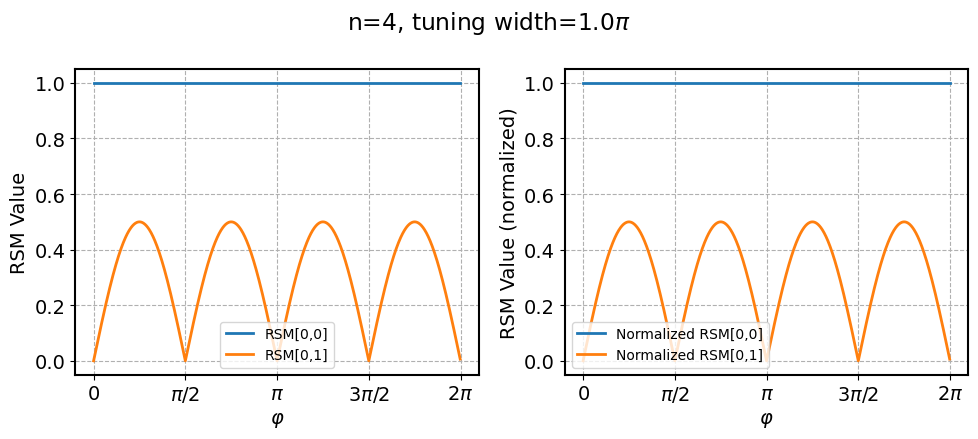

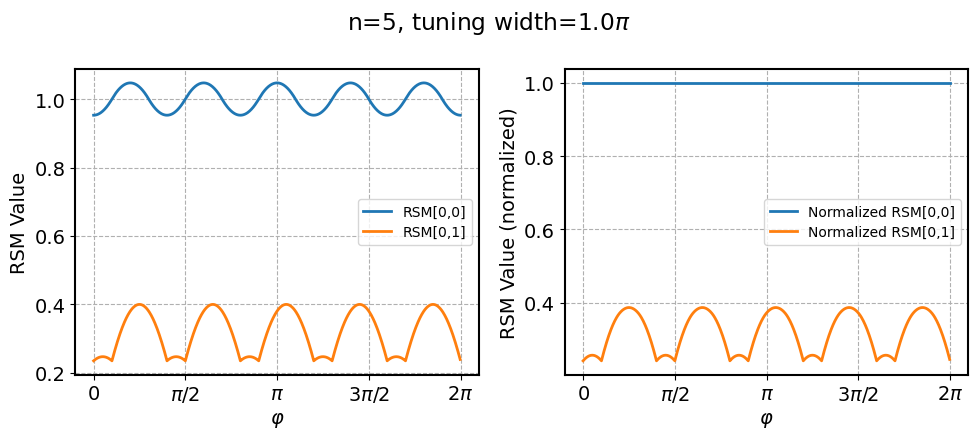

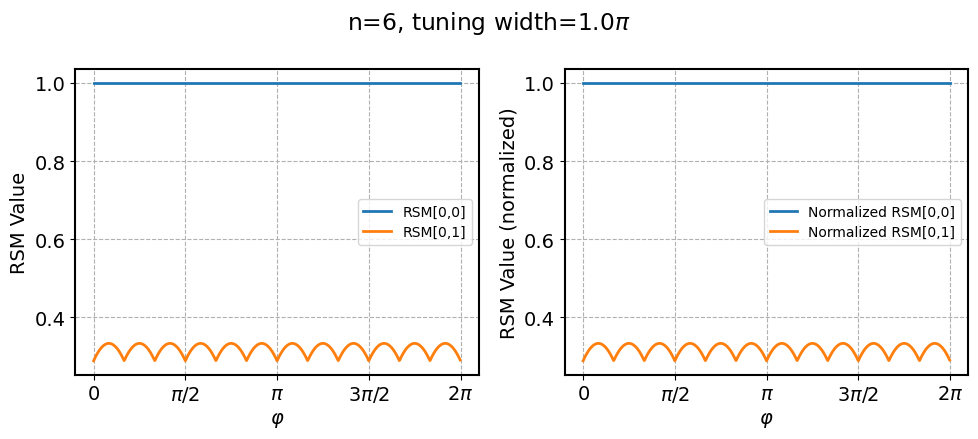

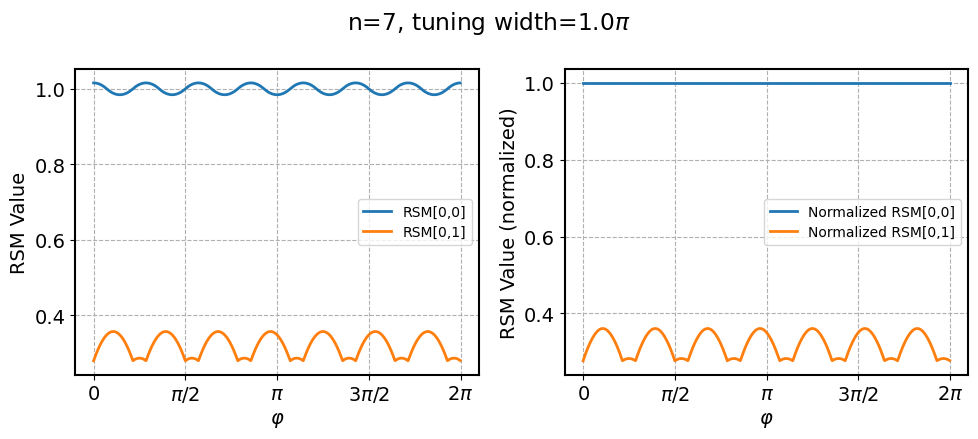

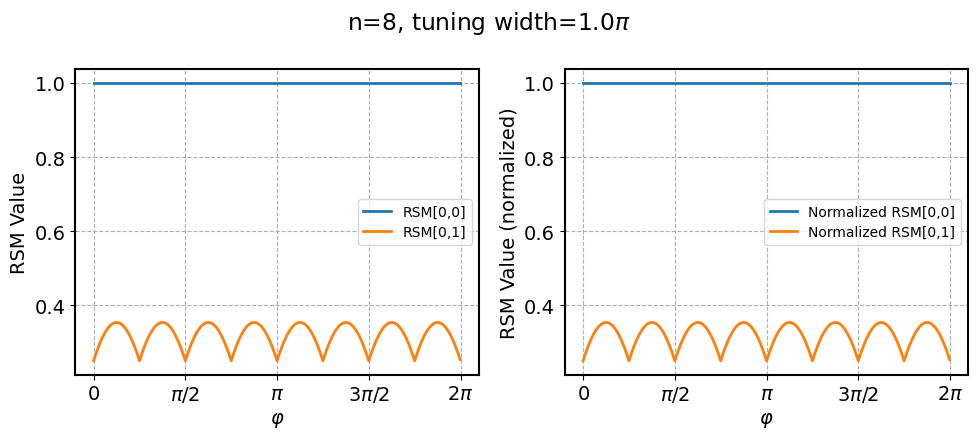

In [18]:
num_neurons_list = [4,5,6,7,8]
num_stims = 4
tuning_width_base = (np.pi)
amp_change_sigma = 0.0

for num_neurons in num_neurons_list:
    Hs =[]; RSMs = []; RSMs_normalized = []
    phis = np.linspace(0, 2*np.pi, 1000, endpoint=False)
    RF_amps = (2/np.sqrt(num_neurons))*np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
    stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T

    for phi in phis:
        tuning_width = tuning_width_base * np.ones(num_neurons)
        RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
        H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
        Hs.append(H)
        RSMs.append(RSM)
        RSMs_normalized.append(RSM_normalized)
        # if phi == phis[3]:
        #     plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM, '$\phi$='+str(round(phi,2)))
    Hs = np.array(Hs); RSMs = np.array(RSMs); RSMs_normalized = np.array(RSMs_normalized)
    RSM_var = np.max(RSMs_normalized, axis=0) - np.min(RSMs_normalized, axis=0)

    # Do a 1 x 2 subplot
    plt.figure(figsize=(10, 4.5))
    plt.subplot(1, 2, 1)
    plt.plot(phis, RSMs[:,0,0], label='RSM[0,0]', color = 'tab:blue')
    #plt.plot(phis, RSMs[:,1,1], label='RSM[1,1]', color = 'tab:green')
    plt.plot(phis, RSMs[:,0,1], label='RSM[0,1]', color = 'tab:orange')
    plt.xlabel(r'$\varphi$')
    plt.ylabel('RSM Value')
    # Set tick positions in radians
    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    # Set tick labels as LaTeX
    tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]

    plt.xticks(ticks, tick_labels)
    plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--")
    # second 
    plt.subplot(1, 2, 2)
    plt.plot(phis, RSMs_normalized[:,0,0], label='Normalized RSM[0,0]', color = 'tab:blue')
    #plt.plot(phis, RSMs_normalized[:,1,1], label='Normalized RSM[1,1]', color = 'tab:green')
    plt.plot(phis, RSMs_normalized[:,0,1], label='Normalized RSM[0,1]', color = 'tab:orange')
    plt.xlabel(r'$\varphi$')
    plt.ylabel('RSM Value (normalized)')
    plt.xticks(ticks, tick_labels)
    plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--")
    plt.suptitle('n=' + str(num_neurons) +', tuning width='+ str(round(tuning_width[0]/np.pi,3)) + r'$\pi$')
    plt.tight_layout()
    if save_figures:
        plt.savefig(fig_folder + '/n='+str(num_neurons)+ 'TW'+ str(round(tuning_width[0]/np.pi,3)) + 'pi_RF_RSM_entries_vs_phi.svg')

# Plot RSM entries vs. $\varphi$ for different tuning widths

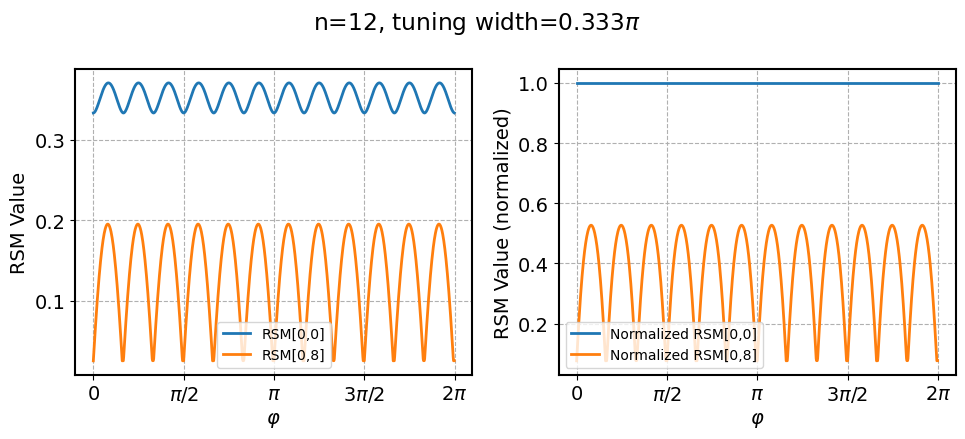

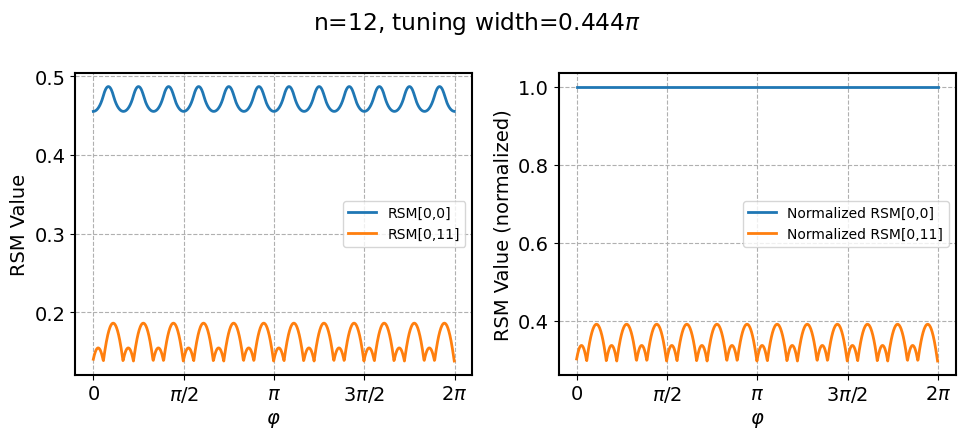

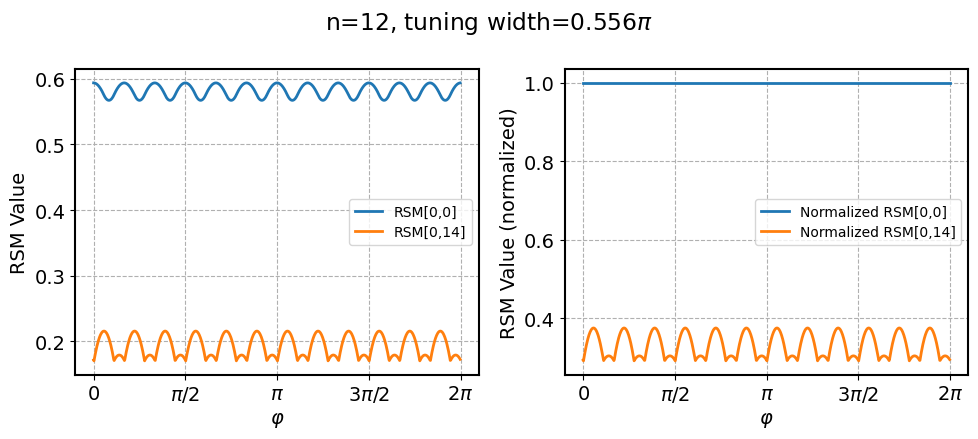

In [19]:
num_neurons = 12
num_stims = 100
tuning_width_base_list = np.linspace(1,2,3,endpoint=False)*4*np.pi/num_neurons
amp_change_sigma = 0.0


for tuning_width_base in tuning_width_base_list:

    Hs =[]; RSMs = []; RSMs_normalized = []
    phis = np.linspace(0, 2*np.pi, 1000, endpoint=False)
    RF_amps = (2/np.sqrt(num_neurons))*np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
    stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T
    stimuli_angles = [a/np.pi for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]


    for phi in phis:
        tuning_width = tuning_width_base * np.ones(num_neurons)
        RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
        H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
        Hs.append(H)
        RSMs.append(RSM)
        RSMs_normalized.append(RSM_normalized)
        # if phi == phis[0]:
        #      plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM, '$\phi$='+str(round(phi,2)))
    Hs = np.array(Hs); RSMs = np.array(RSMs); RSMs_normalized = np.array(RSMs_normalized)
    RSM_var = np.max(RSMs_normalized, axis=0) - np.min(RSMs_normalized, axis=0)

    idxmax = np.argmin(np.abs(np.asarray(stimuli_angles) - (0.5*tuning_width_base/np.pi)))

    # Do a 1 x 2 subplot
    plt.figure(figsize=(10, 4.5))
    plt.subplot(1, 2, 1)
    plt.plot(phis, RSMs[:,0,0], label='RSM[0,0]', color = 'tab:blue')
    plt.plot(phis, RSMs[:,0,idxmax], label='RSM[0,'+str(idxmax)+']', color = 'tab:orange')
    plt.xlabel(r'$\varphi$')
    plt.ylabel('RSM Value')
    # Set tick positions in radians
    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    # Set tick labels as LaTeX
    tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]

    plt.xticks(ticks, tick_labels)
    plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--")
    # second 
    plt.subplot(1, 2, 2)
    plt.plot(phis, RSMs_normalized[:,0,0], label='Normalized RSM[0,'+str(0)+']', color = 'tab:blue')
    plt.plot(phis, RSMs_normalized[:,0,idxmax], label='Normalized RSM[0,'+str(idxmax)+']', color = 'tab:orange')
    plt.xlabel(r'$\varphi$')
    plt.ylabel('RSM Value (normalized)')
    plt.xticks(ticks, tick_labels)
    plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--")
    plt.suptitle('n=' + str(num_neurons) +', tuning width='+ str(round(tuning_width[0]/np.pi,3)) + r'$\pi$')
    plt.tight_layout()
    if save_figures:
        plt.savefig(fig_folder + '/n='+str(num_neurons)+ 'TW'+ str(round(tuning_width[0]/np.pi,3)) + 'pi_RF_RSM_entries_vs_phi.svg')


# RSM variability ($\Delta$) as a function of different variables

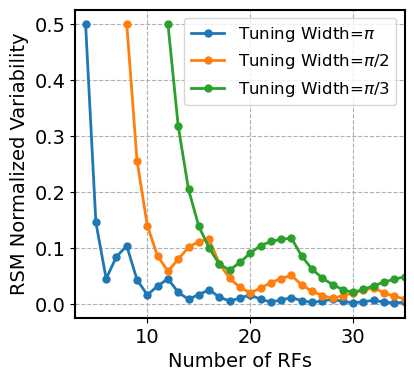

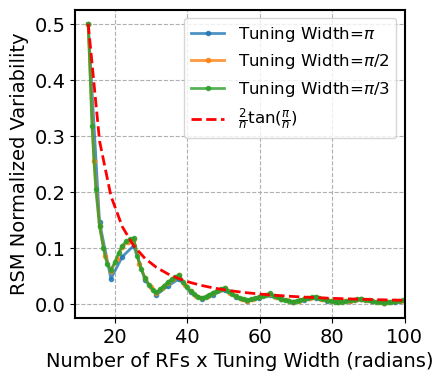

In [20]:
import numpy as np
def rho_n_theory(phi, n):
    phi = phi % (2*np.pi/n)
    return (1/2)* (1/np.tan(2*np.pi/n))*np.cos(2*phi) + (1/2)*np.sin(2*phi)

tuning_width_base_list = [np.pi, np.pi/2, np.pi/3]

# Containers to save data for plotting
all_num_neurons_lists = {}
all_deltas = {}
delta_rho_theory_norm_dict = {}  # only filled for tuning_width_base == np.pi

for tuning_width_base in tuning_width_base_list:

    num_neurons_list = np.arange(int(4*np.pi/tuning_width_base), 120, 1)
    num_stims = int(np.max(4*np.pi/tuning_width_base))
    amp_change_sigma = 0.0

    deltas_ = []

    for num_neurons in num_neurons_list:

        Hs = []
        RSMs = []
        RSMs_normalized = []

        phis = np.linspace(0, 2*np.pi, 1000, endpoint=False)
        RF_amps = (2/np.sqrt(num_neurons))*np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons)
        stimuli = np.array([[np.cos(a), np.sin(a)] 
                            for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T
        stimuli_angles = [a/np.pi for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]

        for phi in phis:
            tuning_width = tuning_width_base * np.ones(num_neurons)
            RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False)
            H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
            Hs.append(H)
            RSMs.append(RSM)
            RSMs_normalized.append(RSM_normalized)

        Hs = np.array(Hs)
        RSMs = np.array(RSMs)
        RSMs_normalized = np.array(RSMs_normalized)
        RSM_var = np.max(RSMs_normalized, axis=0) - np.min(RSMs_normalized, axis=0)

        idxmax = np.argmin(np.abs(np.asarray(stimuli_angles) - (0.5*tuning_width_base/np.pi)))
        delta = np.max(RSMs_normalized[:, 0, idxmax], axis=0) - np.min(RSMs_normalized[:, 0, idxmax], axis=0)
        deltas_.append(delta)

    # Save computed arrays for this tuning_width_base
    all_num_neurons_lists[tuning_width_base] = num_neurons_list
    all_deltas[tuning_width_base] = np.array(deltas_)

    # Save theory curve only for tuning_width_base == np.pi
    if tuning_width_base == np.pi:
        delta_rho_theory_norm = [
            (4/n)*np.abs(rho_n_theory(1*np.pi/n, n) - rho_n_theory(0, n))
            for n in num_neurons_list
        ]
        delta_rho_theory_norm_dict[tuning_width_base] = np.array(delta_rho_theory_norm)



# Plot the results
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(4.25, 4))
fig2, ax2 = plt.subplots(figsize=(4.25, 4))

for tuning_width_base in tuning_width_base_list:
    num_neurons_list = all_num_neurons_lists[tuning_width_base]
    deltas_ = all_deltas[tuning_width_base]

    #label = 'Tuning Width=' + str(round(tuning_width_base/np.pi, 3)) + r'$\pi$'
    # change into pi over fraction for legend
    suffix = '/' + str(int(np.pi/tuning_width_base))
    suffix = suffix.replace('/1', '')
    label = 'Tuning Width=' + r'$\pi$' + suffix

    # First plot: deltas_ vs num_neurons_list
    ax.plot(num_neurons_list, deltas_, '-o', label=label, markersize=5)

    # Second plot: deltas_ vs num_neurons_list * tuning_width_base
    ax2.plot(num_neurons_list * tuning_width_base, deltas_, '-o', label=label, markersize=3, alpha = 0.8)

num_neurons_list = all_num_neurons_lists[np.pi]
ax2.plot(num_neurons_list * np.pi, (2/num_neurons_list)*np.tan(np.pi/num_neurons_list), 'r--', label=r'$\frac{2}{n} \tan(\frac{\pi}{n})$', linewidth=2)
       
   
# Formatting for first figure
ax.set_xlabel('Number of RFs', fontsize=14)
ax.set_ylabel('RSM Normalized Variability', fontsize=14)
ax.grid(True, which="both", ls="--")
ax.legend(fontsize=12)
ax.set_xlim(3, 35)
if save_figures:
    fig.savefig(os.path.join(fig_folder, 'RSM_normalized_variability_vs_num_neurons_and_tuning_width.svg'))

# Formatting for second figure
ax2.set_xlabel('Number of RFs x Tuning Width (radians)', fontsize=14)
ax2.set_ylabel('RSM Normalized Variability', fontsize=14)
ax2.grid(True, which="both", ls="--")
ax2.legend(fontsize=12)
ax2.set_xlim(9, 100)

if save_figures:
    fig2.savefig(os.path.join(fig_folder, 'RSM_normalized_variability_vs_num_neurons_times_tuning_width.svg'))



# Noisy RFs: RSM variability in the presence of amplitude noise

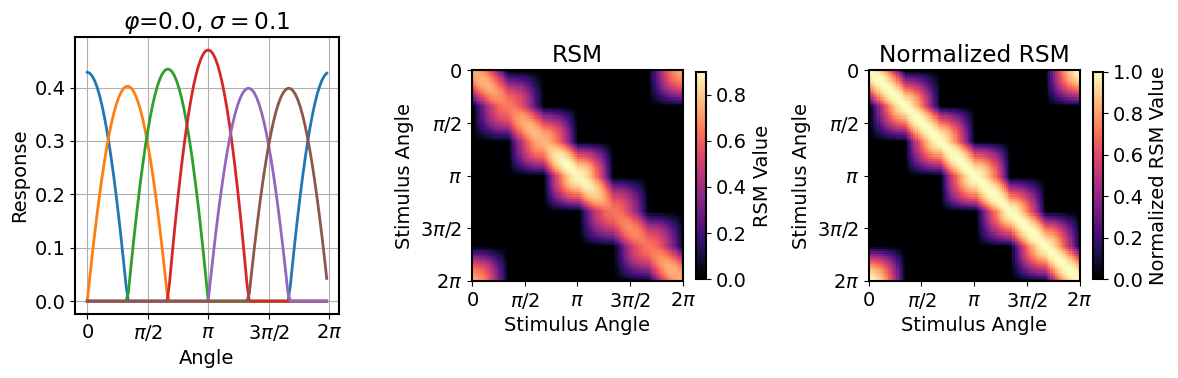

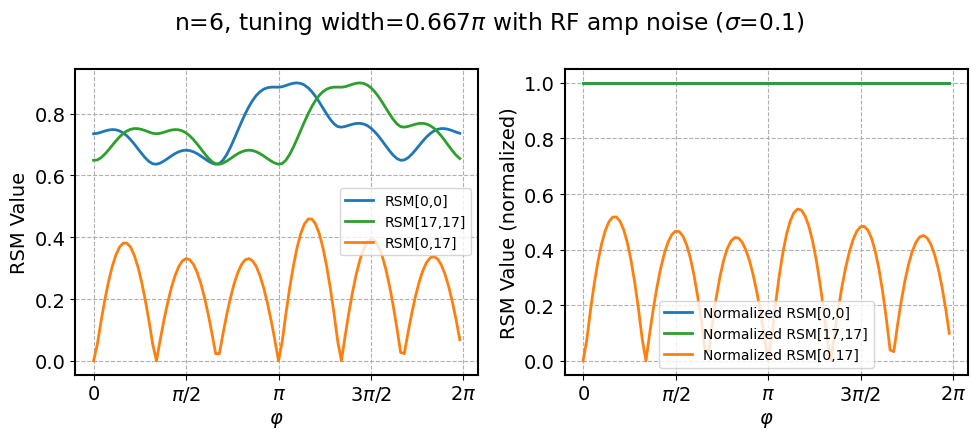

In [21]:
num_neurons = 6
num_stims = 100
tuning_width_base = (4*np.pi/num_neurons)*1
amp_change_sigma = 0.1*1
rf_angle_change_sigma = 0.0

Hs =[]; RSMs = []; RSMs_normalized = []
phis = np.linspace(0, 2*np.pi, 100, endpoint=False)
# set seed
np.random.seed(42)
RF_amps = (2/np.sqrt(num_neurons))* (np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons))
stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T
stimuli_angles = [a/np.pi for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]

rf_angle_noise = rf_angle_change_sigma * np.random.randn(num_neurons)
for phi in phis:
    tuning_width = tuning_width_base* np.ones(num_neurons)
    
    RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False) + rf_angle_noise
    H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
    Hs.append(H)
    RSMs.append(RSM)
    RSMs_normalized.append(RSM_normalized)
    if phi == phis[0]:
        plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM, r'$\varphi$='+str(round(phi,2))  + ', $\sigma=$' + str(amp_change_sigma))
        if save_figures:
            plt.savefig(fig_folder + '/n='+ str(num_neurons) + 'TW' + str(round(tuning_width[0]/np.pi,3)) + 'pi_RF_RSM_with_ampnoise' + str(amp_change_sigma) + '.svg')


Hs = np.array(Hs)
RSMs = np.array(RSMs)
RSMs_normalized = np.array(RSMs_normalized)

idxmax = np.argmin(np.abs(np.asarray(stimuli_angles) - (0.5*tuning_width_base/np.pi)))
# Do a 1 x 2 subplot
plt.figure(figsize=(10, 4.5))
plt.subplot(1, 2, 1)
plt.plot(phis, RSMs[:,0,0], label='RSM[0,0]', color = 'tab:blue')
plt.plot(phis, RSMs[:,idxmax,idxmax], label='RSM['+str(idxmax)+','+str(idxmax)+']', color = 'tab:green')
plt.plot(phis, RSMs[:,0,idxmax], label='RSM[0,'+str(idxmax)+']', color = 'tab:orange')
plt.xlabel(r'$\varphi$')

# Set tick positions in radians
ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
# Set tick labels as LaTeX
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
plt.xticks(ticks, tick_labels)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--")
plt.ylabel('RSM Value')
# second 
plt.subplot(1, 2, 2)

plt.plot(phis, RSMs_normalized[:,0,0], label='Normalized RSM[0,'+str(0)+']', color = 'tab:blue')
plt.plot(phis, RSMs_normalized[:,idxmax,idxmax], label='Normalized RSM['+str(idxmax)+','+str(idxmax)+']', color = 'tab:green')
plt.plot(phis, RSMs_normalized[:,0,idxmax], label='Normalized RSM[0,'+str(idxmax)+']', color = 'tab:orange')
plt.xlabel(r'$\varphi$')
plt.xticks(ticks, tick_labels)
plt.ylabel('RSM Value (normalized)')
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--")
plt.suptitle('n=' + str(num_neurons) +', tuning width='+ str(round(tuning_width[0]/np.pi,3)) + r'$\pi$ with RF amp noise ($\sigma$='+str(amp_change_sigma)+')')
plt.tight_layout()
if save_figures:
    plt.savefig(fig_folder + '/n='+ str(num_neurons) + 'TW' + str(round(tuning_width[0]/np.pi,3)) + 'pi_RF_RSM_entries_vs_phi_with_ampnoise' + str(amp_change_sigma) + '.svg')



# RSM entries vs. $\varphi$ with noisy RFs (multiple realizations)

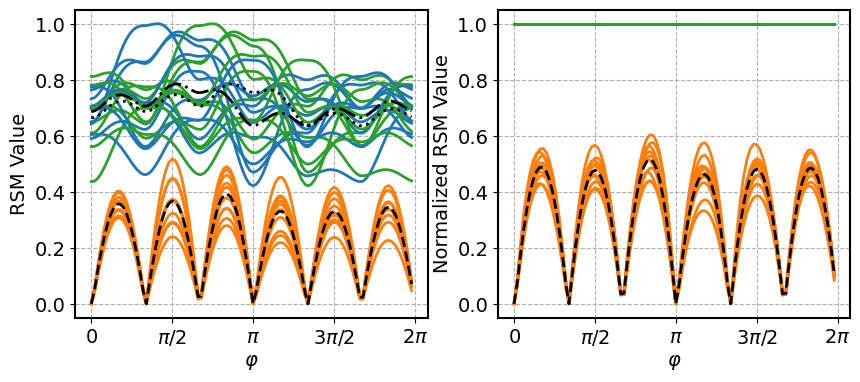

In [22]:
num_neurons = 6
num_stims = 100
tuning_width_base = 4*np.pi/num_neurons
amp_change_sigma = 0.1
rf_angle_change_sigma = 0.0

plt.figure(figsize=(10, 4))
RSMs__normalized_01 = []; RSMs_01 = []
RSMs_00 = []; RSMs_11 = []
for run in range(10):
    Hs =[]; RSMs = []; RSMs_normalized = []
    phis = np.linspace(0, 2*np.pi, 100, endpoint=False)
    RF_amps = (2/np.sqrt(num_neurons))* (np.ones(num_neurons) + amp_change_sigma*np.random.randn(num_neurons))
    stimuli = np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]).T
    stimuli_angles = [a/np.pi for a in np.linspace(0, 2 * np.pi, num_stims, endpoint=False)]

    for phi in phis:
        rf_angle_noise = rf_angle_change_sigma*np.random.randn(num_neurons)
        tuning_width = tuning_width_base * np.ones(num_neurons)
        RF_angles = phi + np.linspace(0, 2 * np.pi, num_neurons, endpoint=False) + rf_angle_noise
        H, RSM, RSM_normalized = RF_responses(stimuli, RF_angles, RF_amps, tuning_width)
        Hs.append(H)
        RSMs.append(RSM)
        RSMs_normalized.append(RSM_normalized)
        #if phi == phis[25]:
            #plot_RF_tuning_curve(RF_angles, RF_amps, tuning_width, RSM)
    Hs = np.array(Hs)
    RSMs = np.array(RSMs)
    RSMs_normalized = np.array(RSMs_normalized)

    idxmax = np.argmin(np.abs(np.asarray(stimuli_angles) - (0.5*tuning_width_base/np.pi)))
    # Do a 1 x 2 subplot
    
    plt.subplot(1, 2, 1)
    plt.plot(phis, RSMs[:,0,0], label='RSM[0,0]', color = 'tab:blue')
    plt.plot(phis, RSMs[:,idxmax,idxmax], label='RSM['+str(idxmax)+','+str(idxmax)+']', color = 'tab:green')
    plt.plot(phis, RSMs[:,0,idxmax], label='RSM[0,'+str(idxmax)+']', color = 'tab:orange')

    plt.xlabel('Phi (radians)')
    plt.ylabel('RSM Value')
    #plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--")
    # second 
    plt.subplot(1, 2, 2)

    plt.plot(phis, RSMs_normalized[:,0,0], label='Normalized RSM[0,'+str(0)+']', color = 'tab:blue')
    plt.plot(phis, RSMs_normalized[:,idxmax,idxmax], label='Normalized RSM['+str(idxmax)+','+str(idxmax)+']', color = 'tab:green')
    plt.plot(phis, RSMs_normalized[:,0,idxmax], label='Normalized RSM[0,'+str(idxmax)+']', color = 'tab:orange')
    plt.xlabel('Phi (radians)')
    plt.ylabel('Normalized RSM Value')
    #plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--")

    RSMs__normalized_01.append(RSMs_normalized[:,0,idxmax])
    RSMs_01.append(RSMs[:,0,idxmax])
    RSMs_00.append(RSMs[:,0,0])
    RSMs_11.append(RSMs[:,idxmax,idxmax])
RSMs__normalized_01 = np.array(RSMs__normalized_01)
RSMs_01 = np.array(RSMs_01)
RSMs_00 = np.array(RSMs_00)
RSMs_11 = np.array(RSMs_11)

plt.subplot(1, 2, 1)
plt.plot(phis, np.mean(np.array(RSMs_01), axis=0), 'k--', label='Mean RSM[0,1] over runs', linewidth=2)
plt.plot(phis, np.mean(np.array(RSMs_00), axis=0), 'k-.', label='Mean RSM[0,0] over runs', linewidth=2)
plt.plot(phis, np.mean(np.array(RSMs_11), axis=0), 'k:', label='Mean RSM[1,1] over runs', linewidth=2)
#plt.ylim([0.5,2])
plt.xlabel(r'$\varphi$')
ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
# Set tick labels as LaTeX
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
plt.xticks(ticks, tick_labels)
plt.subplot(1,2,2)
plt.xticks(ticks, tick_labels)
plt.plot(phis, np.mean(np.array(RSMs__normalized_01), axis=0), 'k--', label='Mean RSM[0,1] over runs', linewidth=2)
#plt.ylim([0.5,1.03])
plt.xlabel(r'$\varphi$')
if save_figures:
    plt.savefig(fig_folder + '/n='+ str(num_neurons) +'_RF_RSM_entries_vs_phi_with_amp_noise.svg')